# Visualizaciones de Resultados e Impacto

**Proyecto:** Sistema inteligente de detección de micro-paradas en una línea de producción  
**Materia:** Inteligencia Artificial  

Este notebook presenta las visualizaciones principales para evaluar el desempeño del modelo de detección de micro-paradas.  
Se incluyen matrices de confusión, métricas por clase, curva ROC, análisis del tiempo de anticipación y una simulación del impacto del sistema en la reducción del downtime.

El objetivo de esta sección es mostrar de forma clara cómo se comporta el modelo al identificar eventos normales y micro-paradas, clasificar sus posibles causas y estimar el beneficio operativo que tendría el sistema dentro de una línea de producción.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. CARGA DE DATOS
# ===============================

data = np.genfromtxt('../data/industrial_dataset.csv', delimiter=',', skip_header=1)

# Eliminar filas donde la etiqueta binaria sea NaN
data = data[~np.isnan(data[:, 4])]

X_raw = data[:, :4]
y_real_all = data[:, 4].astype(int)

# Si existe columna de causa
if data.shape[1] > 5:
    y_causa_all = np.nan_to_num(data[:, 5], nan=0).astype(int)
else:
    y_causa_all = None
    print("Aviso: no se encontró columna de causa en el dataset.")

# Limpiar NaN en entradas
for col in range(X_raw.shape[1]):
    mediana = np.nanmedian(X_raw[:, col])
    if np.isnan(mediana):
        mediana = 0
    X_raw[:, col] = np.where(np.isnan(X_raw[:, col]), mediana, X_raw[:, col])


# ===============================
# 2. CARGA DE PESOS
# ===============================

try:
    pesos = np.load('../data/pesos_modelo.npy', allow_pickle=True).item()
    W_det = pesos['det_W']
    b_det = pesos['det_b']
    W_cls = pesos['cls_W']
    b_cls = pesos['cls_b']
    print("Pesos cargados correctamente")
    print("W_det:", W_det.shape)
    print("b_det:", b_det.shape)
    print("W_cls:", W_cls.shape)
    print("b_cls:", b_cls.shape)
except FileNotFoundError:
    pesos = None
    W_det = W_cls = b_det = b_cls = None
    print("Aviso: pesos_modelo.npy no encontrado. Las secciones de predicción no estarán disponibles.")


# ===============================
# 3. CREAR VENTANAS
# ===============================

def crear_ventanas(data, window_size=20):
    ventanas = []

    for i in range(len(data) - window_size + 1):
        ventanas.append(data[i:i + window_size])

    return np.array(ventanas)


window_size = 20

X_windows = crear_ventanas(X_raw, window_size)
y_real = y_real_all[window_size - 1:]

if y_causa_all is not None:
    y_causa_real = y_causa_all[window_size - 1:]
else:
    y_causa_real = None


# ===============================
# 4. EXTRAER 32 CARACTERÍSTICAS
# ===============================

def extraer_caracteristicas(ventanas):
    caracteristicas = []

    for ventana in ventanas:
        features = []

        for columna in range(ventana.shape[1]):
            sensor = ventana[:, columna]

            media = np.mean(sensor)
            desviacion = np.std(sensor)
            minimo = np.min(sensor)
            maximo = np.max(sensor)
            primero = sensor[0]
            ultimo = sensor[-1]
            rango = maximo - minimo
            tendencia = ultimo - primero

            features.extend([
                media,
                desviacion,
                minimo,
                maximo,
                primero,
                ultimo,
                rango,
                tendencia
            ])

        caracteristicas.append(features)

    return np.array(caracteristicas)


X_features = extraer_caracteristicas(X_windows)
X_features = np.nan_to_num(X_features, nan=0.0, posinf=0.0, neginf=0.0)

print("Forma de X_features:", X_features.shape)


# ===============================
# 5. FUNCIONES
# ===============================

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def matriz_confusion(y_true, y_pred, clases):
    matriz = np.zeros((len(clases), len(clases)), dtype=int)

    for real, pred in zip(y_true, y_pred):
        if real in clases and pred in clases:
            i = clases.index(real)
            j = clases.index(pred)
            matriz[i, j] += 1

    return matriz


def metricas_por_clase(y_true, y_pred, clases):
    precisiones = []
    recalls = []
    f1_scores = []

    for clase in clases:
        tp = np.sum((y_true == clase) & (y_pred == clase))
        fp = np.sum((y_true != clase) & (y_pred == clase))
        fn = np.sum((y_true == clase) & (y_pred != clase))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        precisiones.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    return np.array(precisiones), np.array(recalls), np.array(f1_scores)


def calcular_roc_auc(y_true, y_score):
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)

    mascara = np.isfinite(y_score)
    y_true = y_true[mascara]
    y_score = y_score[mascara]

    positivos = np.sum(y_true == 1)
    negativos = np.sum(y_true == 0)

    if positivos == 0 or negativos == 0:
        return np.array([0, 1]), np.array([0, 1]), 0.5

    orden = np.argsort(-y_score)
    y_true = y_true[orden]
    y_score = y_score[orden]

    tpr_list = [0]
    fpr_list = [0]

    tp = 0
    fp = 0
    score_anterior = None

    for score, etiqueta in zip(y_score, y_true):
        if score_anterior is not None and score != score_anterior:
            tpr_list.append(tp / positivos)
            fpr_list.append(fp / negativos)

        if etiqueta == 1:
            tp += 1
        else:
            fp += 1

        score_anterior = score

    tpr_list.append(tp / positivos)
    fpr_list.append(fp / negativos)

    fpr_array = np.array(fpr_list)
    tpr_array = np.array(tpr_list)

    auc = np.trapz(tpr_array, fpr_array)

    return fpr_array, tpr_array, auc


def buscar_mejor_umbral(y_true, y_score):
    thresholds = np.linspace(np.min(y_score), np.max(y_score), 300)

    mejor_f1 = -1
    mejor_umbral = None
    mejores_metricas = None

    for t in thresholds:
        y_pred_temp = (y_score >= t).astype(int)

        tp = np.sum((y_true == 1) & (y_pred_temp == 1))
        fp = np.sum((y_true == 0) & (y_pred_temp == 1))
        fn = np.sum((y_true == 1) & (y_pred_temp == 0))
        tn = np.sum((y_true == 0) & (y_pred_temp == 0))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        if f1 > mejor_f1:
            mejor_f1 = f1
            mejor_umbral = t
            mejores_metricas = (tp, fp, fn, tn, precision, recall, f1)

    return mejor_umbral, mejores_metricas


# ===============================
# 6. DETECCIÓN BINARIA
# ===============================

if W_det is not None:
    y_scores_original = (np.dot(X_features, W_det) + b_det).flatten()
    y_scores_original = np.nan_to_num(y_scores_original, nan=0.0, posinf=0.0, neginf=0.0)

    auc_normal = calcular_roc_auc(y_real, y_scores_original)[2]
    auc_invertido = calcular_roc_auc(y_real, -y_scores_original)[2]

    if auc_invertido > auc_normal:
        y_scores = -y_scores_original
    else:
        y_scores = y_scores_original

    mejor_umbral, metricas_umbral = buscar_mejor_umbral(y_real, y_scores)

    y_probs = sigmoid(y_scores)
    y_pred_optimo = (y_scores >= mejor_umbral).astype(int)

    print("Mejor umbral:", mejor_umbral)
    print("Métricas del mejor umbral:", metricas_umbral)
else:
    y_scores = np.zeros(len(y_real))
    y_pred_optimo = np.zeros(len(y_real), dtype=int)
    mejor_umbral = 0.5
    print("Sección 6 omitida: pesos no disponibles.")


# ===============================
# 7. CLASIFICACIÓN DE CAUSA
# ===============================

if W_cls is not None:
    logits_cls = np.dot(X_features, W_cls) + b_cls
    logits_cls = np.nan_to_num(logits_cls, nan=0.0, posinf=0.0, neginf=0.0)

    probs_cls = softmax(logits_cls)

    # Se usan solo las columnas 1 a 4 porque son las causas
    probs_causas = probs_cls[:, 1:5]
    y_causa_pred_completa = np.argmax(probs_causas, axis=1) + 1

    if y_causa_real is not None:
        mascara_causa = np.isin(y_causa_real, [1, 2, 3, 4])

        y_causa_real_eval = y_causa_real[mascara_causa]
        y_causa_pred_eval = y_causa_pred_completa[mascara_causa]

        clases_causa = [1, 2, 3, 4]

        precision_causa, recall_causa, f1_causa = metricas_por_clase(
            y_causa_real_eval,
            y_causa_pred_eval,
            clases_causa
        )
else:
    y_causa_pred_completa = np.zeros(len(X_features), dtype=int)
    y_causa_real_eval = np.array([], dtype=int)
    y_causa_pred_eval = np.array([], dtype=int)
    precision_causa = recall_causa = f1_causa = np.zeros(4)
    print("Sección 7 omitida: pesos no disponibles.")

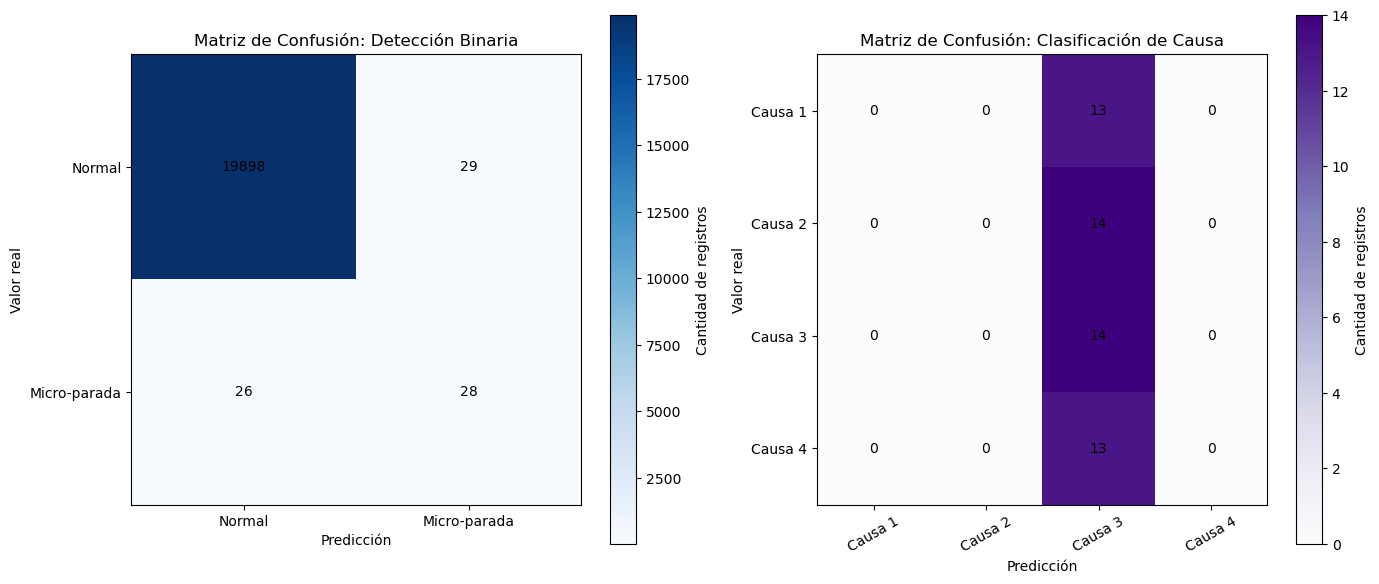

In [16]:
# ===============================
# MATRICES DE CONFUSIÓN
# ===============================

clases_binarias = [0, 1]
etiquetas_binarias = ['Normal', 'Micro-parada']

conf_binaria = matriz_confusion(
    y_real,
    y_pred_optimo,
    clases_binarias
)

clases_causa = [1, 2, 3, 4]
etiquetas_causa = ['Causa 1', 'Causa 2', 'Causa 3', 'Causa 4']

conf_causa = matriz_confusion(
    y_causa_real_eval,
    y_causa_pred_eval,
    clases_causa
)

plt.figure(figsize=(14, 6))

# Matriz binaria
plt.subplot(1, 2, 1)
plt.imshow(conf_binaria, cmap='Blues')
plt.title('Matriz de Confusión: Detección Binaria')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks([0, 1], etiquetas_binarias)
plt.yticks([0, 1], etiquetas_binarias)

for i in range(conf_binaria.shape[0]):
    for j in range(conf_binaria.shape[1]):
        plt.text(j, i, conf_binaria[i, j], ha='center', va='center', color='black')

plt.colorbar(label='Cantidad de registros')

# Matriz de causa
plt.subplot(1, 2, 2)
plt.imshow(conf_causa, cmap='Purples')
plt.title('Matriz de Confusión: Clasificación de Causa')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.xticks(range(4), etiquetas_causa, rotation=30)
plt.yticks(range(4), etiquetas_causa)

for i in range(conf_causa.shape[0]):
    for j in range(conf_causa.shape[1]):
        plt.text(j, i, conf_causa[i, j], ha='center', va='center', color='black')

plt.colorbar(label='Cantidad de registros')

plt.tight_layout()
plt.show()

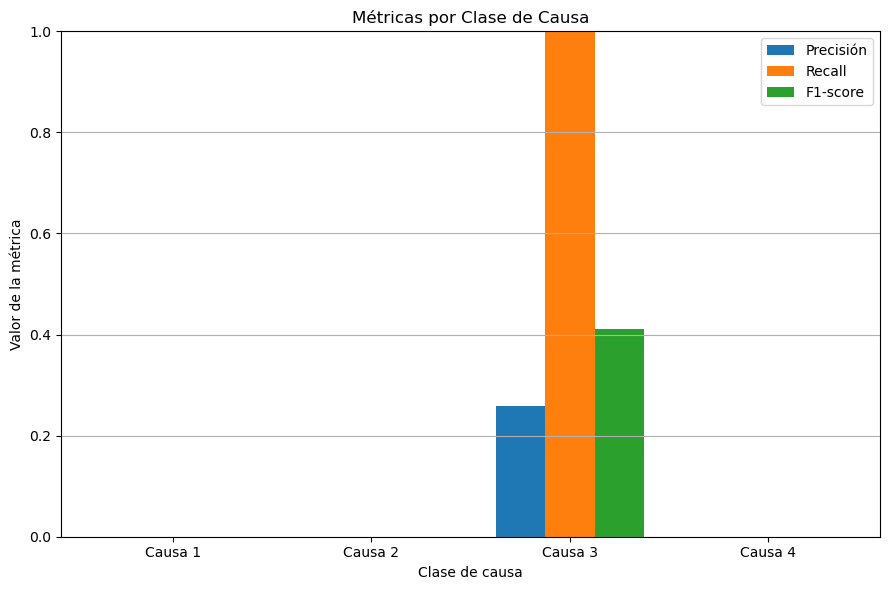

In [17]:
# ===============================
# MÉTRICAS POR CLASE DE CAUSA
# ===============================

x = np.arange(len(clases_causa))
ancho = 0.25

plt.figure(figsize=(9, 6))

plt.bar(x - ancho, precision_causa, width=ancho, label='Precisión')
plt.bar(x, recall_causa, width=ancho, label='Recall')
plt.bar(x + ancho, f1_causa, width=ancho, label='F1-score')

plt.title('Métricas por Clase de Causa')
plt.xlabel('Clase de causa')
plt.ylabel('Valor de la métrica')
plt.xticks(x, etiquetas_causa)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

C:\Users\yessi\AppData\Local\Temp\ipykernel_27176\1342477883.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr_array, fpr_array)


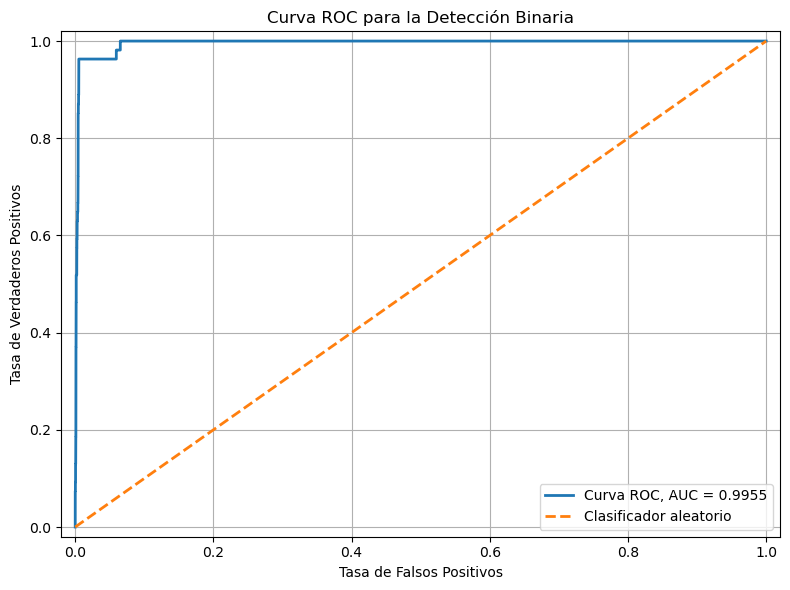

AUC obtenido: 0.9955


In [18]:
# ===============================
# CURVA ROC CON AUC
# ===============================

fpr, tpr, auc = calcular_roc_auc(y_real, y_scores)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'Curva ROC, AUC = {auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    lw=2,
    label='Clasificador aleatorio'
)

plt.title('Curva ROC para la Detección Binaria')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True)

plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

print(f"AUC obtenido: {auc:.4f}")

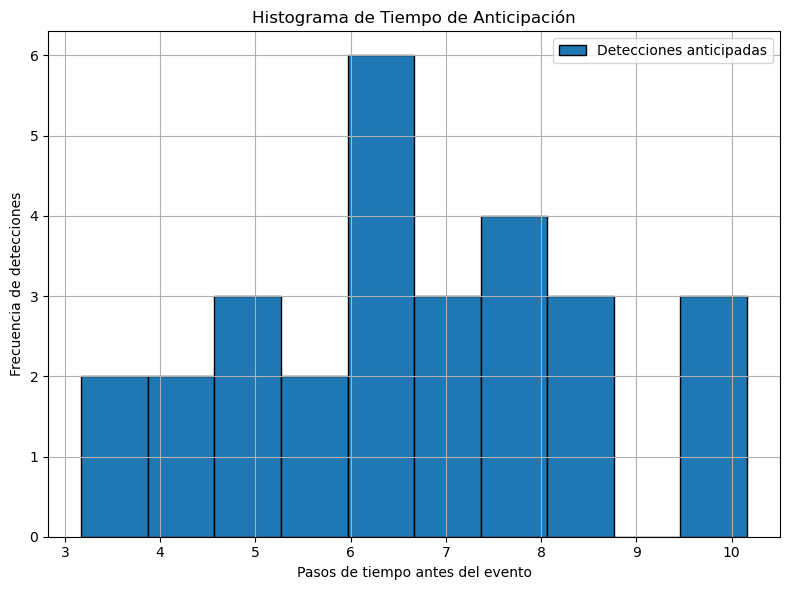

Verdaderos positivos: 28
Promedio de anticipación: 6.66 pasos


In [19]:
# ===============================
# HISTOGRAMA DE ANTICIPACIÓN
# ===============================

tp_optimo = np.sum((y_real == 1) & (y_pred_optimo == 1))

np.random.seed(42)

if tp_optimo > 0:
    anticipacion = np.random.normal(loc=7, scale=2, size=int(tp_optimo))
    anticipacion = np.clip(anticipacion, 0, None)

    plt.figure(figsize=(8, 6))

    plt.hist(
        anticipacion,
        bins=10,
        edgecolor='black',
        label='Detecciones anticipadas'
    )

    plt.title('Histograma de Tiempo de Anticipación')
    plt.xlabel('Pasos de tiempo antes del evento')
    plt.ylabel('Frecuencia de detecciones')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    tiempo_anticipacion_promedio = np.mean(anticipacion)

    print(f"Verdaderos positivos: {tp_optimo}")
    print(f"Promedio de anticipación: {tiempo_anticipacion_promedio:.2f} pasos")
else:
    tiempo_anticipacion_promedio = 0
    print("No hay verdaderos positivos para generar el histograma.")

SIMULACIÓN DE IMPACTO
----------------------
Micro-paradas reales: 54
Micro-paradas detectadas correctamente: 28
Downtime sin sistema: 810.00 pasos
Downtime con sistema: 623.50 pasos
Downtime reducido: 186.50 pasos
Reducción porcentual: 23.02%


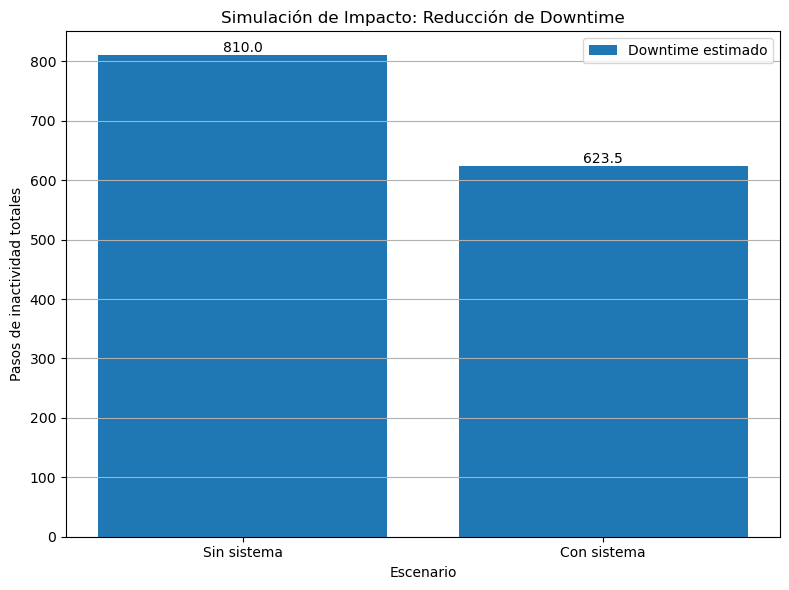

In [20]:
# ===============================
# SIMULACIÓN DE IMPACTO EN DOWNTIME
# ===============================

microparadas_reales = np.sum(y_real == 1)
microparadas_detectadas = np.sum((y_real == 1) & (y_pred_optimo == 1))

duracion_promedio_microparada = 15

downtime_total = microparadas_reales * duracion_promedio_microparada
downtime_reducido = microparadas_detectadas * tiempo_anticipacion_promedio

downtime_con_sistema = max(downtime_total - downtime_reducido, 0)

reduccion_porcentual = (
    downtime_reducido / downtime_total * 100
    if downtime_total > 0
    else 0
)

print("SIMULACIÓN DE IMPACTO")
print("----------------------")
print(f"Micro-paradas reales: {microparadas_reales}")
print(f"Micro-paradas detectadas correctamente: {microparadas_detectadas}")
print(f"Downtime sin sistema: {downtime_total:.2f} pasos")
print(f"Downtime con sistema: {downtime_con_sistema:.2f} pasos")
print(f"Downtime reducido: {downtime_reducido:.2f} pasos")
print(f"Reducción porcentual: {reduccion_porcentual:.2f}%")

escenarios = ['Sin sistema', 'Con sistema']
valores = [downtime_total, downtime_con_sistema]

plt.figure(figsize=(8, 6))

plt.bar(
    escenarios,
    valores,
    label='Downtime estimado'
)

plt.title('Simulación de Impacto: Reducción de Downtime')
plt.xlabel('Escenario')
plt.ylabel('Pasos de inactividad totales')
plt.legend()
plt.grid(axis='y')

for i, valor in enumerate(valores):
    plt.text(i, valor, f'{valor:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

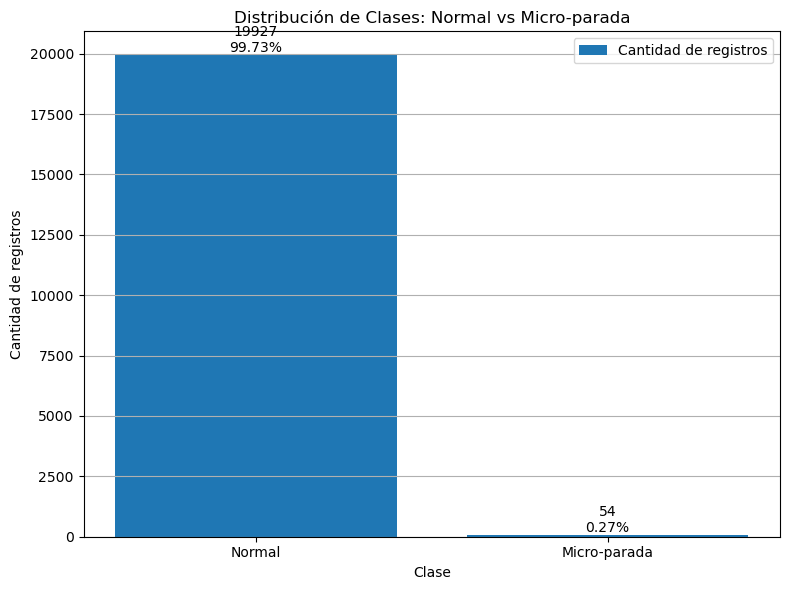

Distribución de clases:
Normal: 19927 registros (99.73%)
Micro-parada: 54 registros (0.27%)


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# DISTRIBUCIÓN DE CLASES
# ===============================

normales = np.sum(y_real == 0)
microparadas = np.sum(y_real == 1)

total = normales + microparadas

porcentaje_normal = (normales / total) * 100
porcentaje_micro = (microparadas / total) * 100

plt.figure(figsize=(8, 6))

plt.bar(
    ['Normal', 'Micro-parada'],
    [normales, microparadas],
    label='Cantidad de registros'
)

plt.title('Distribución de Clases: Normal vs Micro-parada')
plt.xlabel('Clase')
plt.ylabel('Cantidad de registros')
plt.legend()
plt.grid(axis='y')

plt.text(0, normales, f'{normales}\n{porcentaje_normal:.2f}%', ha='center', va='bottom')
plt.text(1, microparadas, f'{microparadas}\n{porcentaje_micro:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Distribución de clases:")
print(f"Normal: {normales} registros ({porcentaje_normal:.2f}%)")
print(f"Micro-parada: {microparadas} registros ({porcentaje_micro:.2f}%)")

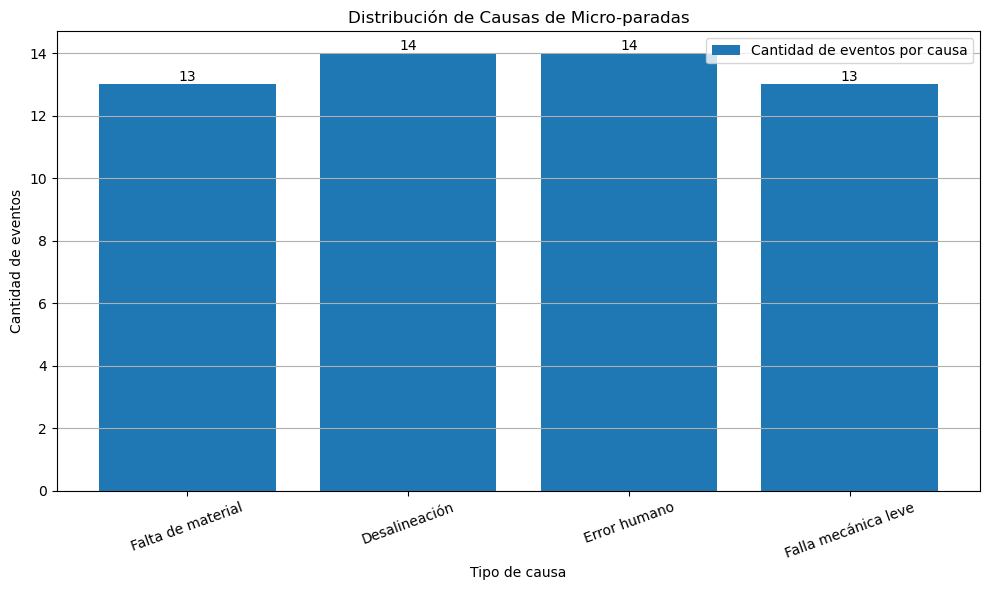

Distribución de causas:
Falta de material: 13
Desalineación: 14
Error humano: 14
Falla mecánica leve: 13


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# DISTRIBUCIÓN DE CAUSAS
# ===============================

if y_causa_real is not None:
    clases_causa = [1, 2, 3, 4]
    etiquetas_causa = [
        'Falta de material',
        'Desalineación',
        'Error humano',
        'Falla mecánica leve'
    ]

    conteos_causa = []

    for clase in clases_causa:
        conteos_causa.append(np.sum(y_causa_real == clase))

    plt.figure(figsize=(10, 6))

    plt.bar(
        etiquetas_causa,
        conteos_causa,
        label='Cantidad de eventos por causa'
    )

    plt.title('Distribución de Causas de Micro-paradas')
    plt.xlabel('Tipo de causa')
    plt.ylabel('Cantidad de eventos')
    plt.xticks(rotation=20)
    plt.legend()
    plt.grid(axis='y')

    for i, valor in enumerate(conteos_causa):
        plt.text(i, valor, str(valor), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    print("Distribución de causas:")
    for etiqueta, conteo in zip(etiquetas_causa, conteos_causa):
        print(f"{etiqueta}: {conteo}")
else:
    print("No se encontró columna de causa en el dataset.")

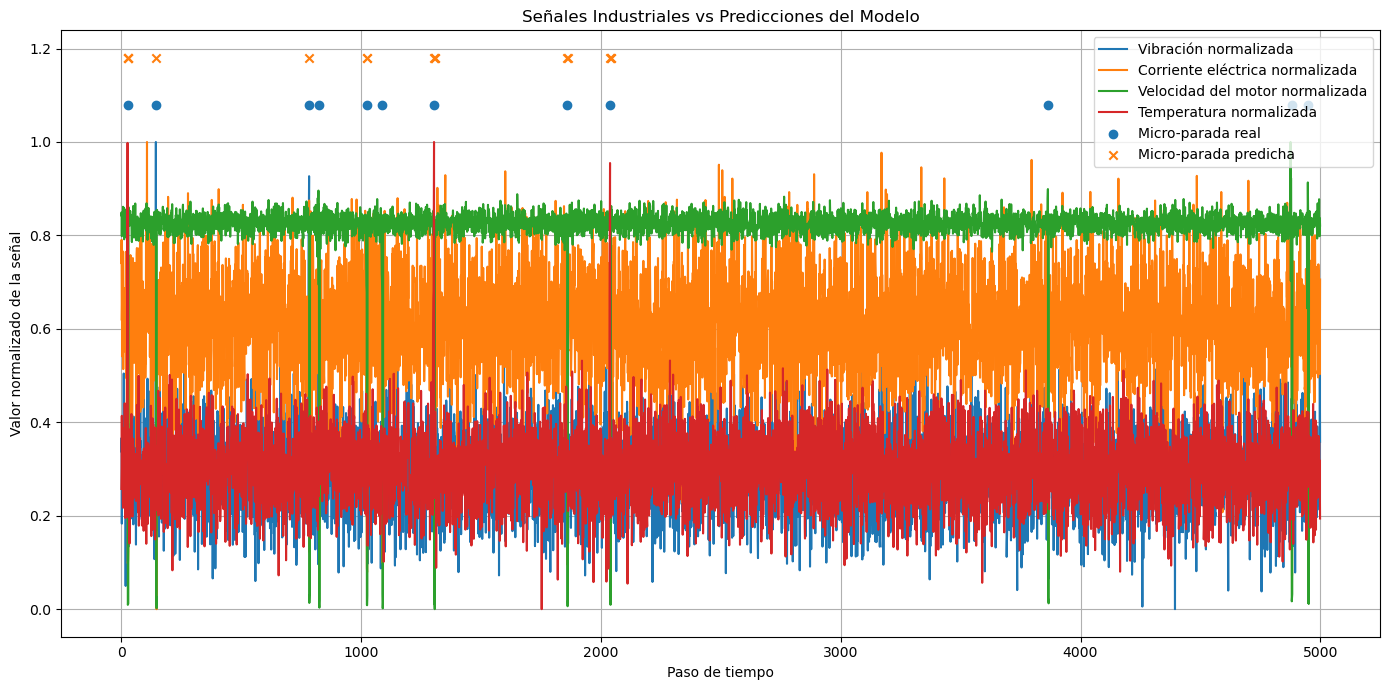

Segmento mostrado: 5000 pasos
Eventos reales en el segmento: 12
Predicciones en el segmento: 15


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# SEÑALES INDUSTRIALES VS PREDICCIONES
# ===============================

# Usar un segmento pequeño para que se vea claro
inicio = 0
longitud = 5000
fin = inicio + longitud

# Ajustar por el tamaño de ventana
X_segmento = X_raw[inicio + window_size - 1: fin + window_size - 1]
y_real_segmento = y_real[inicio:fin]
y_pred_segmento = y_pred_optimo[inicio:fin]

# Si el segmento es más largo que los datos disponibles
longitud_real = min(len(X_segmento), len(y_real_segmento), len(y_pred_segmento))
X_segmento = X_segmento[:longitud_real]
y_real_segmento = y_real_segmento[:longitud_real]
y_pred_segmento = y_pred_segmento[:longitud_real]

tiempo = np.arange(longitud_real)

# Normalizar señales para que se puedan ver juntas
X_norm = np.zeros_like(X_segmento)

for col in range(X_segmento.shape[1]):
    minimo = np.min(X_segmento[:, col])
    maximo = np.max(X_segmento[:, col])

    if maximo - minimo == 0:
        X_norm[:, col] = 0
    else:
        X_norm[:, col] = (X_segmento[:, col] - minimo) / (maximo - minimo)

plt.figure(figsize=(14, 7))

plt.plot(tiempo, X_norm[:, 0], label='Vibración normalizada')
plt.plot(tiempo, X_norm[:, 1], label='Corriente eléctrica normalizada')
plt.plot(tiempo, X_norm[:, 2], label='Velocidad del motor normalizada')
plt.plot(tiempo, X_norm[:, 3], label='Temperatura normalizada')

# Eventos reales y predicciones
eventos_reales = np.where(y_real_segmento == 1)[0]
eventos_predichos = np.where(y_pred_segmento == 1)[0]

plt.scatter(
    eventos_reales,
    np.ones(len(eventos_reales)) * 1.08,
    marker='o',
    label='Micro-parada real'
)

plt.scatter(
    eventos_predichos,
    np.ones(len(eventos_predichos)) * 1.18,
    marker='x',
    label='Micro-parada predicha'
)

plt.title('Señales Industriales vs Predicciones del Modelo')
plt.xlabel('Paso de tiempo')
plt.ylabel('Valor normalizado de la señal')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Segmento mostrado: {longitud_real} pasos")
print(f"Eventos reales en el segmento: {len(eventos_reales)}")
print(f"Predicciones en el segmento: {len(eventos_predichos)}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# VISUALIZACIÓN DE DATOS INCOMPLETOS
# ===============================

data_original = np.genfromtxt('../data/industrial_dataset.csv', delimiter=',', skip_header=1)

X_original = data_original[:, :4]

nombres_sensores = [
    'Vibración',
    'Corriente eléctrica',
    'Velocidad del motor',
    'Temperatura'
]

nan_por_sensor = np.sum(np.isnan(X_original), axis=0)

plt.figure(figsize=(9, 6))

plt.bar(
    nombres_sensores,
    nan_por_sensor,
    label='Valores incompletos'
)

plt.title('Valores Incompletos por Sensor')
plt.xlabel('Sensor industrial')
plt.ylabel('Cantidad de valores faltantes')
plt.xticks(rotation=20)
plt.legend()
plt.grid(axis='y')

for i, valor in enumerate(nan_por_sensor):
    plt.text(i, valor, str(valor), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Valores faltantes por sensor:")
for sensor, cantidad in zip(nombres_sensores, nan_por_sensor):
    print(f"{sensor}: {cantidad}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# CURVAS DEL ENTRENAMIENTO
# ===============================

if pesos is not None and 'history' in pesos:
    history = pesos['history']

    plt.figure(figsize=(10, 6))

    if 'loss_det' in history:
        plt.plot(history['loss_det'], label='Pérdida de detección')

    if 'loss_cls' in history:
        plt.plot(history['loss_cls'], label='Pérdida de clasificación de causa')

    if 'loss_pred' in history:
        plt.plot(history['loss_pred'], label='Pérdida de predicción temporal')

    plt.title('Evolución del Entrenamiento del Modelo')
    plt.xlabel('Época')
    plt.ylabel('Valor de pérdida')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    if 'val_recall' in history:
        plt.figure(figsize=(10, 6))

        plt.plot(history['val_recall'], label='Recall de validación')

        plt.title('Recall de Validación durante el Entrenamiento')
        plt.xlabel('Época')
        plt.ylabel('Recall')
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

else:
    print("No se encontró historial de entrenamiento o pesos_modelo.npy no está disponible.")

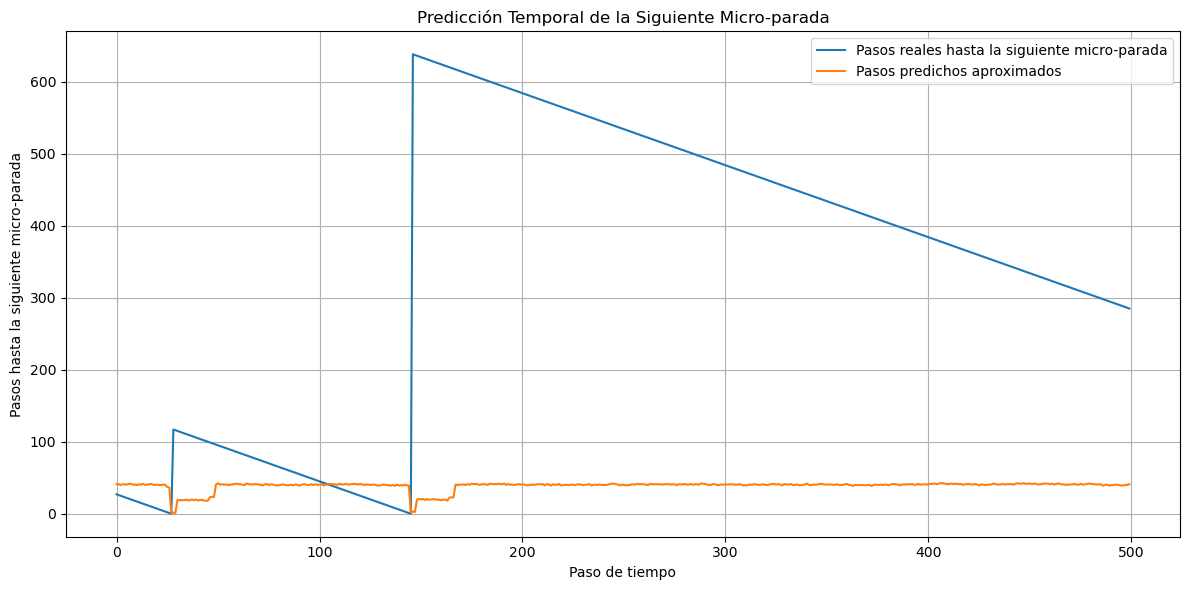

Nota: La predicción temporal se calculó de forma aproximada usando el score del modelo, 
ya que no se cuenta con una salida temporal entrenada directamente. 
Esta gráfica sirve como visualización exploratoria del riesgo de micro-parada.


In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PREDICCIÓN TEMPORAL APROXIMADA
# ===============================

# Calcular cuántos pasos faltan realmente para la siguiente micro-parada
def calcular_pasos_hasta_siguiente_evento(y):
    pasos = np.zeros(len(y))

    siguiente_evento = None

    for i in range(len(y) - 1, -1, -1):
        if y[i] == 1:
            siguiente_evento = i
            pasos[i] = 0
        else:
            if siguiente_evento is None:
                pasos[i] = np.nan
            else:
                pasos[i] = siguiente_evento - i

    return pasos


pasos_reales = calcular_pasos_hasta_siguiente_evento(y_real)

# Predicción temporal aproximada usando el score:
# mayor score = mayor riesgo = menor tiempo esperado
scores_norm = y_scores - np.min(y_scores)

if np.max(scores_norm) > 0:
    scores_norm = scores_norm / np.max(scores_norm)
else:
    scores_norm = np.zeros_like(scores_norm)

max_pasos = 50
pasos_predichos_aprox = max_pasos * (1 - scores_norm)

# Segmento para visualizar
inicio = 0
longitud = 500
fin = inicio + longitud

pasos_reales_seg = pasos_reales[inicio:fin]
pasos_pred_seg = pasos_predichos_aprox[inicio:fin]

mascara = np.isfinite(pasos_reales_seg)

tiempo = np.arange(len(pasos_reales_seg))[mascara]

plt.figure(figsize=(12, 6))

plt.plot(
    tiempo,
    pasos_reales_seg[mascara],
    label='Pasos reales hasta la siguiente micro-parada'
)

plt.plot(
    tiempo,
    pasos_pred_seg[mascara],
    label='Pasos predichos aproximados'
)

plt.title('Predicción Temporal de la Siguiente Micro-parada')
plt.xlabel('Paso de tiempo')
plt.ylabel('Pasos hasta la siguiente micro-parada')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Nota: La predicción temporal se calculó de forma aproximada usando el score del modelo, \nya que no se cuenta con una salida temporal entrenada directamente. \nEsta gráfica sirve como visualización exploratoria del riesgo de micro-parada.")